# **Prototypical Networks for Few-Shot Image Classification**
Flowers102 benchmark · 5-way 1-shot · PyTorch · RGB real-world images

---

## Results

| Metric | Value |
|---|---|
| Test accuracy | 73.11% ± 12.90% |
| Training accuracy (epoch 15) | 93.56% |
| Random baseline (5-way) | 20.00% |
| Classes | 102 flower species |
| Episodes evaluated | 300 |
| Model parameters | 113,088 |
| Episode Accuracy | 76.0%

---

## Overview

This project extends few-shot learning from handwritten character recognition to real-world RGB image classification across 102 flower species. The core challenge is harder than standard benchmarks: flowers share similar colors, textures, and shapes across species, making one-shot generalization genuinely difficult.

---

## Method

Prototypical Networks (Snell et al., 2017) learn an embedding space where images from the same class cluster together. Each class is represented by one prototype, the mean of its support embeddings. A query image is assigned to the nearest prototype by Euclidean distance.

Training follows an episodic structure simulating real few-shot conditions. Each episode is one 5-way 1-shot task: 5 random flower species, 1 support image per species, 5 query images to classify. The model is trained on 1000 episodes per epoch across 15 epochs and evaluated on 300 episodes drawn from 6149 held-out test images.

---

## Motivation

This project was built as preparation for research on few-shot object detection. Flowers102 was chosen deliberately over simpler benchmarks because real-world visual similarity between classes reflects the actual difficulty of detection tasks in the wild, where novel object categories often share visual features with known ones.

---

## Reference

Snell, J., Swersky, K., & Zemel, R. (2017). Prototypical Networks for Few-shot Learning. NeurIPS 2017.

In [11]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

api_token = {"username":"azeezalsmn","key":"KGAT_d32d3a623e5853204cbcbe15f56bf628"}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(api_token, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Done.')

Done.


In [12]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((84, 84)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_set = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
val_set   = torchvision.datasets.Flowers102(root='./data', split='val',   download=True, transform=transform)
test_set  = torchvision.datasets.Flowers102(root='./data', split='test',  download=True, transform=transform)

print(f'Train: {len(train_set)} images')
print(f'Val:   {len(val_set)} images')
print(f'Test:  {len(test_set)} images')

Train: 1020 images
Val:   1020 images
Test:  6149 images


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [14]:
# Episode Sampler
class EpisodeSampler(Dataset):
    def __init__(self, dataset, n_way=5, k_shot=1, n_query=5, n_episodes=500):
        self.n_way = n_way
        self.k_shot = k_shot
        self.n_query = n_query
        self.n_episodes = n_episodes

        self.class_to_images = defaultdict(list)
        for img, label in dataset:
            self.class_to_images[label].append(img)

        self.classes = [
            c for c, imgs in self.class_to_images.items()
            if len(imgs) >= k_shot + n_query
        ]
        print(f'Usable classes: {len(self.classes)}')

    def __len__(self):
        return self.n_episodes

    def __getitem__(self, _):
        episode_classes = random.sample(self.classes, self.n_way)
        support_images, support_labels = [], []
        query_images, query_labels = [], []

        for local_label, cls in enumerate(episode_classes):
            images = self.class_to_images[cls]
            selected = random.sample(images, self.k_shot + self.n_query)
            support_images.extend(selected[:self.k_shot])
            query_images.extend(selected[self.k_shot:])
            support_labels.extend([local_label] * self.k_shot)
            query_labels.extend([local_label] * self.n_query)

        return (
            torch.stack(support_images), torch.tensor(support_labels),
            torch.stack(query_images),   torch.tensor(query_labels)
        )

In [15]:
# Starting Meta-Learning
from torch.utils.data import ConcatDataset
meta_train = ConcatDataset([train_set, val_set])
meta_test  = test_set

train_episodes = EpisodeSampler(meta_train, n_way=5, k_shot=1, n_query=5, n_episodes=1000)
test_episodes  = EpisodeSampler(meta_test,  n_way=5, k_shot=1, n_query=5, n_episodes=300)

train_loader = DataLoader(train_episodes, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_episodes,  batch_size=1, shuffle=False)

Usable classes: 102
Usable classes: 102


In [16]:
# Embedding Network
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

class EmbeddingNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            conv_block(3, 64),   # 3 channels for RGB
            conv_block(64, 64),
            conv_block(64, 64),
            conv_block(64, 64)
        )
    def forward(self, x):
        return self.encoder(x).view(x.size(0), -1)

model     = EmbeddingNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 113,088


In [17]:
# Prototypical Loss
def prototypical_loss(support_emb, support_lbls, query_emb, query_lbls, n_way):
    prototypes = torch.stack([
        support_emb[support_lbls == c].mean(0) for c in range(n_way)
    ])
    dists     = torch.cdist(query_emb, prototypes)
    log_probs = F.log_softmax(-dists, dim=1)
    loss      = F.nll_loss(log_probs, query_lbls)
    acc       = (log_probs.argmax(1) == query_lbls).float().mean().item()
    return loss, acc

In [18]:
# Training
N_WAY, N_EPOCHS = 5, 15
train_losses, train_accs = [], []

for epoch in range(N_EPOCHS):
    model.train()
    ep_loss, ep_acc = 0.0, 0.0

    for s_imgs, s_lbls, q_imgs, q_lbls in train_loader:
        s_imgs = s_imgs.squeeze(0).to(device)
        s_lbls = s_lbls.squeeze(0).to(device)
        q_imgs = q_imgs.squeeze(0).to(device)
        q_lbls = q_lbls.squeeze(0).to(device)

        loss, acc = prototypical_loss(model(s_imgs), s_lbls, model(q_imgs), q_lbls, N_WAY)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item(); ep_acc += acc

    n = len(train_loader)
    train_losses.append(ep_loss / n)
    train_accs.append(ep_acc / n)
    print(f'Epoch {epoch+1:02d}/{N_EPOCHS} | Loss: {ep_loss/n:.4f} | Acc: {ep_acc/n*100:.2f}%')


Epoch 01/15 | Loss: 1.1162 | Acc: 61.49%
Epoch 02/15 | Loss: 0.8132 | Acc: 68.91%
Epoch 03/15 | Loss: 0.7158 | Acc: 73.02%
Epoch 04/15 | Loss: 0.6579 | Acc: 74.62%
Epoch 05/15 | Loss: 0.5903 | Acc: 77.38%
Epoch 06/15 | Loss: 0.5259 | Acc: 79.81%
Epoch 07/15 | Loss: 0.4585 | Acc: 82.87%
Epoch 08/15 | Loss: 0.4029 | Acc: 84.69%
Epoch 09/15 | Loss: 0.3577 | Acc: 86.75%
Epoch 10/15 | Loss: 0.3161 | Acc: 88.21%
Epoch 11/15 | Loss: 0.2705 | Acc: 90.05%
Epoch 12/15 | Loss: 0.2533 | Acc: 90.70%
Epoch 13/15 | Loss: 0.2088 | Acc: 92.44%
Epoch 14/15 | Loss: 0.2037 | Acc: 92.71%
Epoch 15/15 | Loss: 0.1785 | Acc: 93.56%


In [19]:
# EValuation
model.eval()
test_accs = []

with torch.no_grad():
    for s_imgs, s_lbls, q_imgs, q_lbls in test_loader:
        s_imgs = s_imgs.squeeze(0).to(device)
        s_lbls = s_lbls.squeeze(0).to(device)
        q_imgs = q_imgs.squeeze(0).to(device)
        q_lbls = q_lbls.squeeze(0).to(device)
        _, acc = prototypical_loss(model(s_imgs), s_lbls, model(q_imgs), q_lbls, N_WAY)
        test_accs.append(acc)

print(f'\nTest Accuracy: {np.mean(test_accs)*100:.2f}% +/- {np.std(test_accs)*100:.2f}%')
print(f'Random baseline (5-way): 20.00%')


Test Accuracy: 73.11% +/- 12.90%
Random baseline (5-way): 20.00%


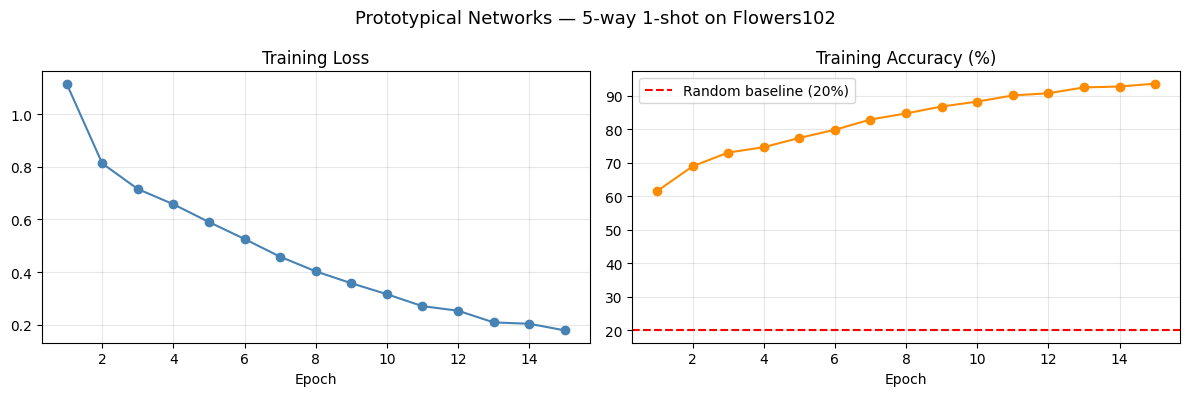

Training Loss and Accuracy.


In [20]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, N_EPOCHS+1), train_losses, marker='o', color='steelblue')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, N_EPOCHS+1), [a*100 for a in train_accs], marker='o', color='darkorange')
axes[1].axhline(20, color='red', linestyle='--', label='Random baseline (20%)')
axes[1].set_title('Training Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Prototypical Networks — 5-way 1-shot on Flowers102', fontsize=13)
plt.tight_layout()
plt.savefig('flowers_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training Loss and Accuracy.')

In [21]:
# Visualize one episode with actual flower images
sample = next(iter(test_loader))
s_imgs, s_lbls, q_imgs, q_lbls = sample

s_imgs = s_imgs.squeeze(0).to(device)
s_lbls = s_lbls.squeeze(0).to(device)
q_imgs = q_imgs.squeeze(0).to(device)
q_lbls = q_lbls.squeeze(0).to(device)

with torch.no_grad():
    s_emb = model(s_imgs)
    q_emb = model(q_imgs)
    dists = torch.cdist(q_emb, torch.stack([s_emb[s_lbls==c].mean(0) for c in range(N_WAY)]))
    preds = dists.argmin(dim=1).cpu()

q_lbls_cpu = q_lbls.cpu()

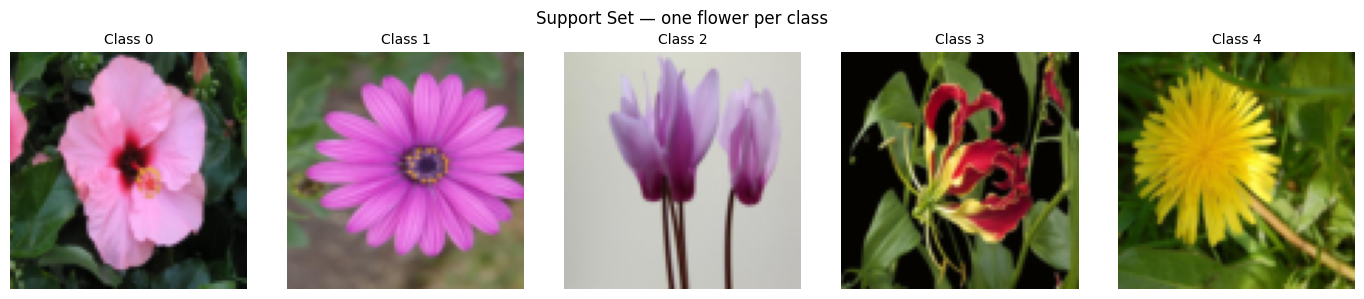

In [22]:
# Denormalize so images look natural
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    return (t.cpu() * std + mean).clamp(0,1).permute(1,2,0).numpy()

# Show support set
fig, axes = plt.subplots(1, N_WAY, figsize=(14, 3))
fig.suptitle('Support Set — one flower per class', fontsize=12)
for i in range(N_WAY):
    axes[i].imshow(denorm(s_imgs[i]))
    axes[i].set_title(f'Class {i}', fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('support_set.png', dpi=150, bbox_inches='tight')
plt.show()

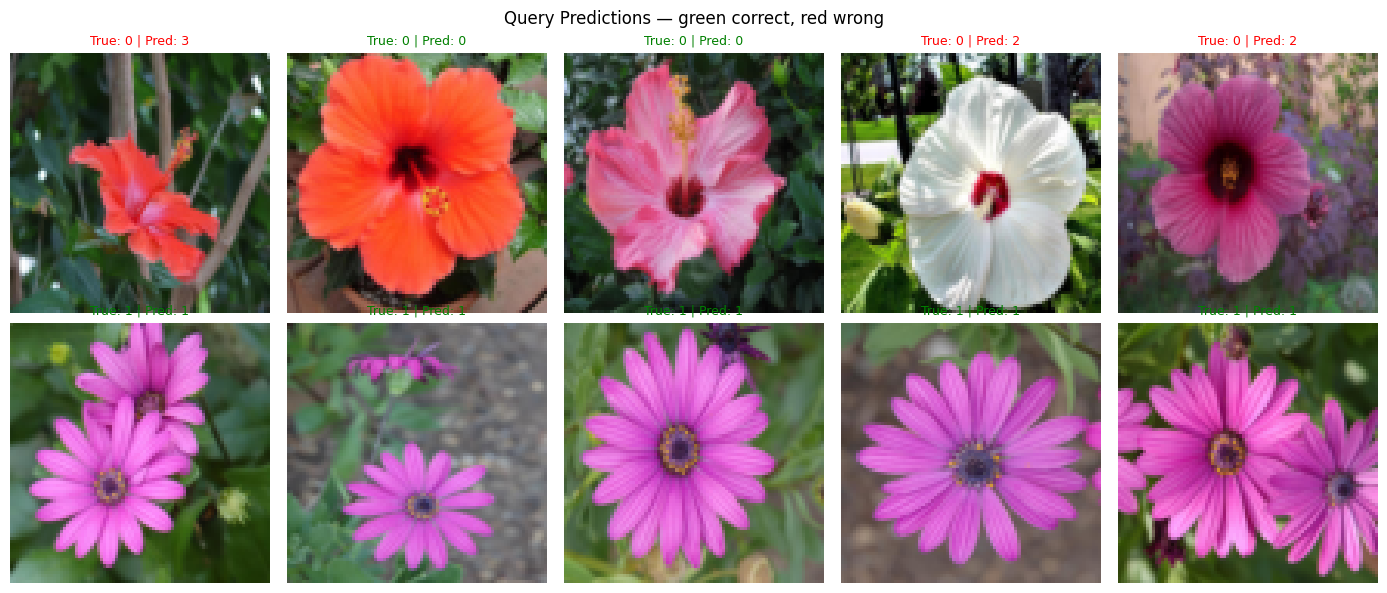

Episode accuracy: 76.0%


In [23]:
# Show query predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Query Predictions — green correct, red wrong', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(q_imgs[i]))
    correct = preds[i].item() == q_lbls_cpu[i].item()
    color = 'green' if correct else 'red'
    ax.set_title(f'True: {q_lbls_cpu[i].item()} | Pred: {preds[i].item()}', color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('query_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

ep_acc = (preds == q_lbls_cpu).float().mean().item() * 100
print(f'Episode accuracy: {ep_acc:.1f}%')